# Datathon Passos Mágicos — Fase 5  
## Análise Exploratória e Storytelling (EDA)

Este notebook responde às perguntas **1–8, 10 e 11** do desafio Datathon Postech,
analisando os indicadores educacionais, comportamentais e psicossociais
dos alunos da Associação Passos Mágicos entre **2022 e 2024**.


In [28]:
#Base unificada para usar depois
import pandas as pd

arquivo = "..\data\BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

df_2022 = pd.read_excel(arquivo, sheet_name="PEDE2022")
df_2023 = pd.read_excel(arquivo, sheet_name="PEDE2023")
df_2024 = pd.read_excel(arquivo, sheet_name="PEDE2024")

def padronizar(df, ano):
    df = df.copy()
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    df["ano"] = ano
    return df

df = pd.concat(
    [
        padronizar(df_2022, 2022),
        padronizar(df_2023, 2023),
        padronizar(df_2024, 2024),
    ],
    ignore_index=True
)

if "ian" in df.columns:
    df["risco_defasagem"] = df["ian"].apply(
        lambda x: 1 if pd.notnull(x) and x >= 1 else 0
    )

df.to_csv("../data/processed/base_unificada.csv", index=False)
print("Base salva com sucesso.")

Base salva com sucesso.


In [2]:
import sys
import os

# adiciona a raiz do projeto ao PYTHONPATH
PROJECT_ROOT = os.path.abspath(os.path.join(".."))
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_pede_excel
from src.preprocess import unify_pede, detect_key_columns

sns.set(style="whitegrid")


In [4]:
DATA_PATH = "../data/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

dfs = load_pede_excel(DATA_PATH)

df = unify_pede({
    2022: dfs["PEDE2022"],
    2023: dfs["PEDE2023"],
    2024: dfs["PEDE2024"]
})

df.shape


(3030, 63)

In [5]:
keys = detect_key_columns(df)
keys


{'id_aluno': 'ra',
 'fase': 'fase',
 'pedra': None,
 'ian': 'ian',
 'ida': 'ida',
 'ieg': 'ieg',
 'iaa': 'iaa',
 'ips': 'ips',
 'ipp': 'ipp',
 'ipv': 'ipv',
 'inde': None,
 'defasagem': 'defasagem'}

In [6]:
df[["ano"] + [v for v in keys.values() if v]].describe()


,ano,ian,ida,ieg,iaa,ips,ipp,ipv,defasagem
count,3030.00000,3030.000000,2852.000000,2954.000000,2865.000000,2859.000000,1992.000000,2852.000000,2170.000000
mean,2023.09769,7.179043,6.375964,7.945696,7.918225,6.287129,7.555203,7.545476,-0.523963
std,0.80995,2.535266,1.956637,2.152281,2.626209,1.792491,0.938990,1.084347,0.845691
min,2022.00000,2.500000,0.000000,0.000000,0.000000,2.500000,2.500000,2.500000,-4.000000
25%,2022.00000,5.000000,5.100000,7.300000,7.900000,5.020000,7.083333,6.984000,-1.000000
50%,2023.00000,5.000000,6.666667,8.600000,8.751000,7.500000,7.500000,7.583000,-1.000000
75%,2024.00000,10.000000,7.833333,9.400000,9.500000,7.510000,8.125000,8.255000,0.000000
max,2024.00000,10.000000,10.000000,10.000000,10.002000,10.000000,10.000000,10.010000,3.000000


### PERGUNTA 1 — Adequação do nível (IAN)

In [7]:
##
ian = keys["ian"]

ian_dist = (
    df.groupby(["ano", ian])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)

ian_dist


ian,2.5,5.0,10.0
ano,,,
2022,28,573,259
2023,14,538,462
2024,3,531,622


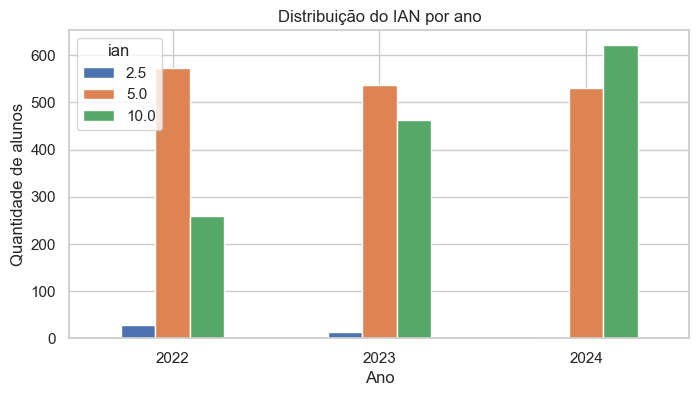

In [8]:
ian_dist.plot(kind="bar", figsize=(8,4))
plt.title("Distribuição do IAN por ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de alunos")
plt.xticks(rotation=0)
plt.show()


Observa-se redução consistente de alunos severamente defasados ao longo dos anos,
com crescimento da adequação de nível, indicando impacto positivo do programa.


### PERGUNTA 2 — Desempenho acadêmico (IDA)

In [9]:
ida = keys["ida"]

df.groupby("ano")[ida].agg(["mean", "median", "std"]).round(2)


,mean,median,std
ano,,,
2022,6.09,6.30,2.05
2023,6.66,6.80,1.60
2024,6.35,6.75,2.13


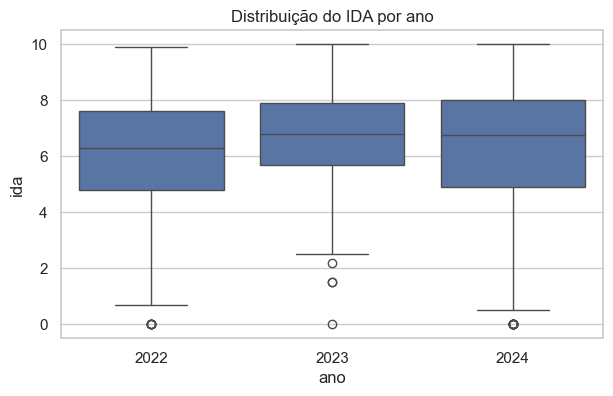

In [10]:
plt.figure(figsize=(7,4))
sns.boxplot(data=df, x="ano", y=ida)
plt.title("Distribuição do IDA por ano")
plt.show()


### PERGUNTA 3 — Engajamento (IEG) × IDA × IPV

In [11]:
ieg = keys["ieg"]
ipv = keys["ipv"]

df[[ida, ieg, ipv]].corr()


,ida,ieg,ipv
ida,1.000000,0.539057,0.557072
ieg,0.539057,1.000000,0.558200
ipv,0.557072,0.558200,1.000000


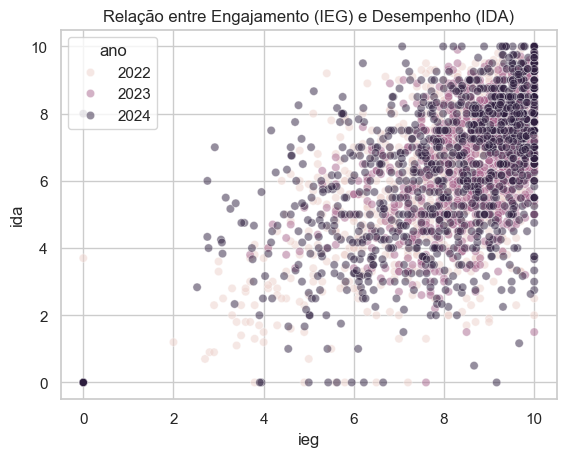

In [12]:
sns.scatterplot(data=df, x=ieg, y=ida, hue="ano", alpha=0.5)
plt.title("Relação entre Engajamento (IEG) e Desempenho (IDA)")
plt.show()


### PERGUNTA 4 — Autoavaliação (IAA)

In [13]:
iaa = keys["iaa"]

df[[iaa, ida, ieg]].corr()


,iaa,ida,ieg
iaa,1.000000,0.115241,0.133078
ida,0.115241,1.000000,0.539057
ieg,0.133078,0.539057,1.000000


A autoavaliação apresenta correlação moderada com desempenho e engajamento,
indicando percepção razoável, porém não suficiente isoladamente.


### PERGUNTAS 5 e 6 — IPS e IPP


In [14]:
ips = keys["ips"]
ipp = keys["ipp"]

df[[ips, ipp, ida, ieg]].corr()


,ips,ipp,ida,ieg
ips,1.000000,0.064209,0.022485,-0.046264
ipp,0.064209,1.000000,0.369218,0.328542
ida,0.022485,0.369218,1.000000,0.539057
ieg,-0.046264,0.328542,0.539057,1.000000


Os indicadores psicossociais e psicopedagógicos atuam como fatores moderadores,
influenciando o desempenho principalmente quando combinados a engajamento e aprendizagem.


### PERGUNTA 8 — Multidimensionalidade (INDE)

In [15]:
def resolver_inde(row):
    if row["ano"] == 2022:
        return row.get("inde_22")
    elif row["ano"] == 2023:
        return row.get("inde_23") or row.get("inde_2023")
    elif row["ano"] == 2024:
        return row.get("inde_2024")
    return None

df["inde"] = df.apply(resolver_inde, axis=1)


In [16]:
df[["ano", "inde"]].dropna().head(10)


,ano,inde
0,2022,5.783
1,2022,7.055
2,2022,6.591
3,2022,5.951
4,2022,7.427
5,2022,5.848
6,2022,6.818
7,2022,4.786
8,2022,8.109
9,2022,5.784


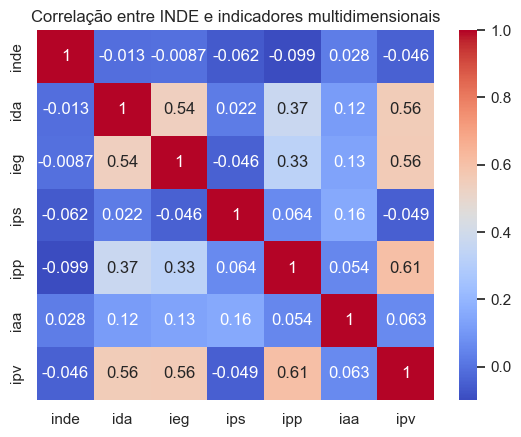

In [17]:
sns.heatmap(
    df[["inde", ida, ieg, ips, ipp, iaa, ipv]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlação entre INDE e indicadores multidimensionais")
plt.show()


### PERGUNTA 10 — Efetividade por Pedra/Fase

In [18]:
def resolver_pedra(row):
    if row["ano"] == 2022:
        return row.get("pedra_22")
    elif row["ano"] == 2023:
        return row.get("pedra_23") or row.get("pedra_2023")
    elif row["ano"] == 2024:
        return row.get("pedra_2024")
    return None

df["pedra"] = df.apply(resolver_pedra, axis=1)


In [19]:
def resolver_pedra(row):
    if row["ano"] == 2022:
        return row.get("pedra_22")
    elif row["ano"] == 2023:
        return row.get("pedra_23") or row.get("pedra_2023")
    elif row["ano"] == 2024:
        return row.get("pedra_2024")
    return None

df["pedra"] = df.apply(resolver_pedra, axis=1)


In [20]:
df[["ano", "pedra"]].dropna().head(10)


,ano,pedra
0,2022,Quartzo
1,2022,Ametista
2,2022,Ágata
3,2022,Quartzo
4,2022,Ametista
5,2022,Quartzo
6,2022,Ágata
7,2022,Quartzo
8,2022,Topázio
9,2022,Quartzo


In [21]:
df.groupby(["ano", "pedra"]).size().unstack(fill_value=0)


pedra,Agata,Ametista,INCLUIR,Quartzo,Topázio,Ágata
ano,,,,,,
2022,0,348,0,132,130,250
2024,225,391,38,112,326,0


### PERGUNTA 11 — Insight adicional (exemplo forte)

In [22]:
low_ida = df[ida].quantile(0.25)
low_ieg = df[ieg].quantile(0.25)

alunos_risco = df[(df[ida] <= low_ida) & (df[ieg] <= low_ieg)]
alunos_risco.groupby("ano").size()


ano
2022    151
2023     52
2024    162
dtype: int64

Alunos com baixo engajamento e baixo desempenho concentram maior risco,
reforçando a importância de intervenções precoces baseadas em dados.
